# Task 4: Predicting Insurance Claim Amounts

## 1. Introduction and Problem Statement
**Objective:** Estimate the medical insurance claim amount (charges) based on personal data like age, BMI, and smoking habits.

**The Mental Model (Linear Regression):** Imagine we are building a pricing machine with several "dials" (our features: age, BMI, smoking status). Linear Regression tries to find the perfect setting for each dial. It learns exactly how much to turn up the final "medical bill" dial every time a patient gets one year older, or if they flip the "smoker" switch to YES. Our goal is to train this machine to guess the bill as accurately as possible.

# Imports & Dataset Understanding

In [1]:
# Importing necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv('insurance.csv')

# Display the first 5 rows to understand the structure
display(df.head())

# Check data types and basic info
print("\n--- Dataset Info ---")
df.info()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 2. Dataset Understanding and Description
The dataset contains 1,338 patient records and 7 columns. 
* **Numerical Data:** `age`, `bmi`, `children`, `charges` (our target).
* **Categorical Data (Text):** `sex`, `smoker`, `region`.

In [2]:
# Step 1: Check for missing data (null values)
print("Missing Values:\n", df.isnull().sum())

# Step 2: Convert Categorical Data to Numbers (One-Hot Encoding)
# Machine learning models can only do math on numbers, not text like "yes" or "no".
# pd.get_dummies turns text categories into binary columns (1s and 0s).
# drop_first=True prevents redundant columns (e.g., if it's not 'male', it must be 'female', so we only need one column).

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print("\n--- Data After Encoding ---")
display(df_encoded.head())

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Data After Encoding ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## 3. Data Cleaning and Preparation
**The Mental Model (One-Hot Encoding):**
A computer doesn't know what the word "smoker" means. We use one-hot encoding to turn that text into a light switch. Now, the model sees a column called `smoker_yes`. If the value is `1`, the switch is ON (they smoke). If it is `0`, the switch is OFF. We've translated human language into math.

## 4. Exploratory Data Analysis (EDA) Insights
By visualizing the data, we can spot clear patterns before we even train the model:
1. **Age:** There is a steady, linear increase in charges as people get older.
2. **Smoking:** This is the biggest separator. In the boxplot and scatter plots, smokers (red dots) are consistently grouped at the highest charge levels.
3. **The BMI Danger Zone:** High BMI alone doesn't always cause massive charges. However, if you look at the top right of the BMI scatter plot, being a smoker *combined* with a high BMI causes medical charges to skyrocket.

C:\Users\User\AppData\Local\Temp\ipykernel_22096\3122512123.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')


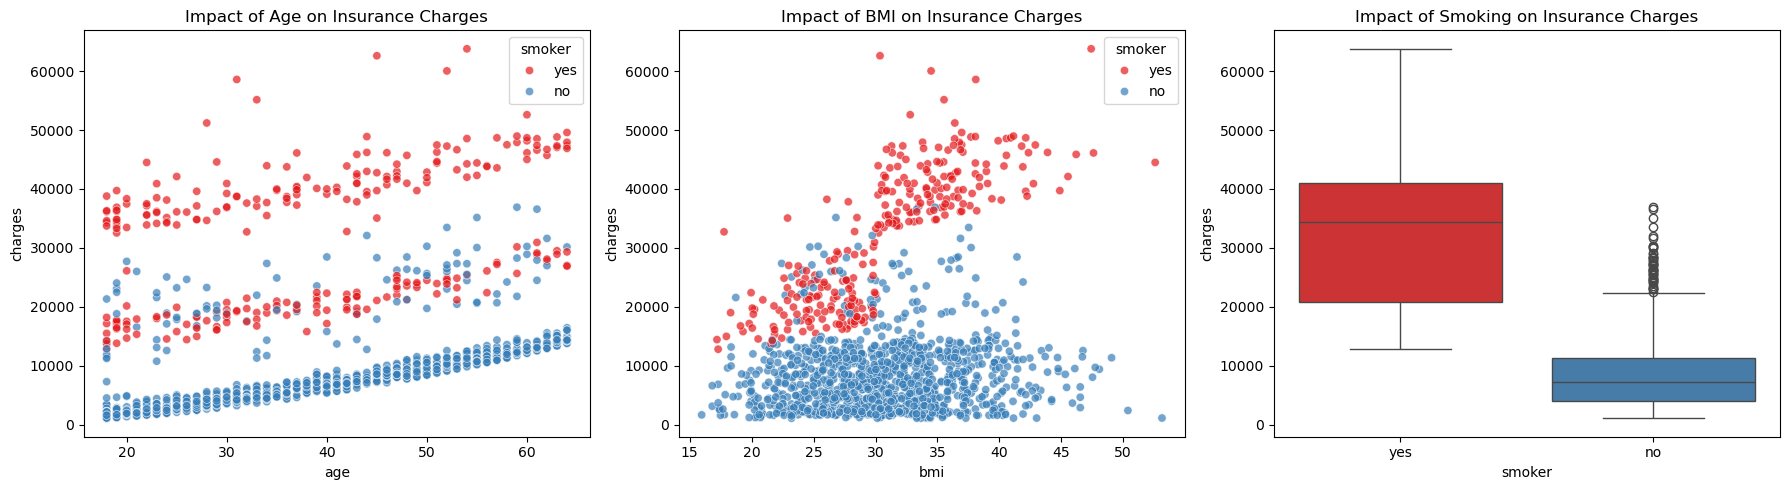

In [3]:
# Set up a wide canvas for 3 side-by-side graphs
plt.figure(figsize=(18, 5))

# Graph 1: Age vs. Charges
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Impact of Age on Insurance Charges')

# Graph 2: BMI vs. Charges
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Impact of BMI on Insurance Charges')

# Graph 3: Smoking Status vs. Charges
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1')
plt.title('Impact of Smoking on Insurance Charges')

# Adjust layout and show
plt.tight_layout()
plt.show()

## 5. Model Training and Testing
**The Mental Model (Train/Test Split):**
Why do we split the data 80/20? Imagine taking a math class. The 80% `X_train` data is the homework assignments you use to learn the concepts. The 20% `X_test` data is the final exam. If the teacher gave you the exact same questions on the final exam that were on the homework, they wouldn't know if you actually learned math, or if you just memorized the answers. We hold back 20% of the data to prove our model actually understands the underlying patterns.

In [4]:
# Step 1: Separate the features (X) from the target we want to predict (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Step 2: Split the data into Training and Testing sets
# We hold back 20% of the data so we can test the model on "unseen" patients later.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train) # The model is looking at the training data and finding the "line of best fit"

# Step 4: Make Predictions on the test set
y_pred = model.predict(X_test)

## 6. Evaluation Metrics
**The Mental Model (MAE vs. RMSE):**
* **MAE (Mean Absolute Error):** This is the model's average mistake. If MAE is $4,181, it means on average, our model's guess is off by roughly four thousand dollars. It treats all mistakes equally.
* **RMSE (Root Mean Squared Error):** Because this formula squares the errors before averaging them, it acts as a **strict teacher that punishes massive mistakes**. 

If RMSE ($5,796) is significantly higher than MAE ($4,181), it tells us that while the model is usually pretty accurate, it occasionally makes massive, catastrophic errors on a few specific "outlier" patients (likely those complex cases with high BMI and smoking).

In [5]:
# Calculate Error Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28


## 7. Conclusion
**Key Insights:**
1. **Smoking is the primary driver of cost.** The EDA clearly shows that being a smoker exponentially increases medical claims.
2. **Compounding Variables:** While age and BMI cause moderate increases in charges, the *combination* of a high BMI and smoking creates the highest medical charges in the entire dataset. 
3. **Model Limitations:** Linear regression provided a solid baseline to understand these relationships. However, the gap between our MAE and RMSE suggests that a simple straight line struggles to perfectly capture the complex, compounding jumps in cost (like the extreme spike when obesity and smoking combine). Future work could explore non-linear models like Random Forests to better predict these extreme cases.